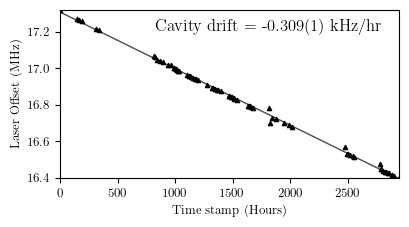

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
import graph_style

graph_style.set_graph_style(1)


def unpack_data(path):
    """Download data from Grafana with "Formatted data" disabled."""
    df = pd.read_csv(path, header=[0])
    df = df[df["artiq.mean"].notna()]
    df["Time (s)"] = (df["Time"] - df["Time"].min()) * 1e-3

    t = df["Time (s)"].values
    f = df["artiq.mean"].values * 1e6
    return t, f


path = r"729 offset (rel. to lock)-data-2025-05-15 20_47_34.csv"

t, f = unpack_data(path)

t = t / (60 * 60)  # convert to hours
f = f / 10**6  # convert to MHz
# Remove rogue outlier
mask = f <= 2 * 10**1
f = f[mask]
t = t[mask]

def linear_func(x, m, b):
    return m * x + b
lin_fit = linear_func
p_fit, p_cov = curve_fit(lin_fit, t, f)
p_errs = np.sqrt(np.diag(p_cov))

fig_width = graph_style.get_fig_width()*0.75
fig_height = fig_width /2
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

ax.scatter(t, f, zorder=11,color="k")
ax.plot(t, lin_fit(t, *p_fit), ls="-", zorder=10, alpha=graph_style.get_alpha(), color="k")
ax.set_xlabel("Time stamp (Hours)")
ax.set_ylabel("Laser Offset (MHz)")
ax.set_xlim(0, max(t))
ax.set_ylim(min(f), max(f))

# Add fitted parameters to top-right
textstr = f"Cavity drift = {p_fit[0]*1000:.3f}({p_errs[0]*1000*1000:.0f}) kHz/hr"

# Place in top right corner (axes coords)
ax.text(
    0.95,
    0.95,
    textstr,
    transform=ax.transAxes,
    verticalalignment="top",
    horizontalalignment="right",
    fontsize=12,
)
ax.grid(False)

plt.savefig("../../pdf_figure/ch3/cavity_drift.pdf", bbox_inches="tight")
